# Tutorial05 · Spam Email Classification

From simple rules to reliable decisions

**Tutor:** Yinghao Zhu · yhzhu99@connect.hku.hk

Build a text classifier that catches unwanted messages while preserving legitimate ones, and justify how its scores become inbox decisions.

Start by recognizing spam yourself and designing a keyword rule. Its failures lead to measurable features, learned word evidence, regularization and fair model selection. Every stage answers a problem raised by the previous one. The SMS Spam Collection supplies short, inspectable labelled messages; it lets us learn spam-filtering methods without treating a historical SMS benchmark as evidence about modern email.

## Learning route

1. **Start with the inbox** — What should a spam filter actually do?
2. **Know the data** — What does this dataset let us learn?
3. **Build observable features** — What can we measure before understanding language?
4. **Turn words into vectors** — How can the model use the actual words?
5. **Learn a weighted rule** — How do word counts become a spam score?
6. **Control the fitted rule** — Should one rare word receive a huge weight?
7. **Select with cross-validation** — What must be fitted again inside each fold?
8. **Model the class distributions** — What changes if we model the features within each class?
9. **Allow smooth feature effects** — Must each extra character change the score by the same amount?
10. **Learn from similar messages** — What makes two messages neighbours?
11. **Choose the final decision** — How should scores become inbox actions?

## Learning objectives

- Explain the dataset’s origin, its SMS-to-email limitations, class imbalance and the roles of training, CV, validation and test data.
- Construct a keyword baseline, numerical features, count vectors and TF–IDF; explain what each representation preserves or discards.
- Connect logistic coefficients and message-specific contributions to scores, probabilities and regularization.
- Use leakage-safe pipelines and stratified CV to select hyperparameters without using the test set.
- Compare LDA, a binomial additive spline model and KNN through their assumptions, visual mechanisms and validation errors.
- Choose and justify a model and threshold, inspect both error types and report a frozen decision’s test result.

**Prerequisites:** Basic Python and NumPy; logistic regression and GLMs, LDA, classification evaluation, cross-validation, regularization, data preprocessing, GAMs and nearest neighbours. We connect these taught ideas to text classification; no SVM, tree or ensemble knowledge is required.

**Outcome:** An executed notebook covering every chapter, with transparent baselines, representation and model comparisons, training-only CV, a justified threshold, final test metrics and a documented limitation.

Each section explains the mechanism, plots or inspects an actual computation, then runs an editable experiment. All sections form the classroom lesson.

## Data source and setup

# Original UCI SMS Spam Collection

**Source:** Almeida, T. A. and Gómez Hidalgo, J. M. (2011), SMS Spam Collection,
UCI Machine Learning Repository.
https://archive.ics.uci.edu/dataset/228/sms+spam+collection
Dataset DOI: https://doi.org/10.24432/C5CC84
Original archive: https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip

`SMSSpamCollection.txt` contains the original archive's `SMSSpamCollection` bytes,
unchanged; only the local filename has a `.txt` extension. Downloaded 2026-10-05.
It has 5,574 tab-separated label/message records: 4,827 ham and 747 spam.
UCI currently lists CC BY 4.0; original attribution/terms are in SOURCE-LICENSE.txt.

**Paper:** Almeida, T. A., Gómez Hidalgo, J. M., and Yamakami, A. (2011),
“Contributions to the Study of SMS Spam Filtering: New Collection and Results,”
ACM Symposium on Document Engineering. https://doi.org/10.1145/2034691.2034742

The English messages were compiled from Grumbletext (UK spam complaints), the NUS
SMS Corpus (volunteer messages, largely Singaporean students), Caroline Tagg's PhD
research and the SMS Spam Corpus v0.1 Big. It is a compiled research corpus, not a
random sample of today's inboxes. Messages are not chronologically ordered.

Why use it: short inspectable examples, explicit binary labels, manageable local training,
class imbalance and repeated messages make representation and evaluation choices visible.
Despite the tutorial title Spam Email Classification, these are SMS messages, without
email senders, subjects, attachments or headers. Text-classification methods transfer;
measured performance does not establish results on modern email, phishing, other
languages or another population. Constructed inbox cards are illustrative examples.

The loader checks empty/placeholder messages, normalizes case/whitespace solely for
message identity, rejects conflicting labels, and keeps one record per identity before
splitting. It reports every count and preserves retained message text. Splits are
stratified 60% train / 20% validation / 20% test (seed 3612). Five-fold CV uses training
only. Vocabulary, IDF, scaling and spline knots belong inside each fold's fitted pipeline.

SHA-256 of the unchanged original file:
7d039a24a6083ed9ef0f806ebad56bbb976e3aeb8de05669173bfdc4996c239d  src/tutorials/tutorial05/data/SMSSpamCollection.txt


Extract the complete student package. Keep `experiment.py` beside this notebook and retain `data/`. Install `requirements.txt`, then run cells in order. The original file is bundled locally; no dataset download or NLTK resources are required.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import experiment as science
from experiment import (Experiment, SEED, FEATURES, TOKEN_PATTERN, tokens, numerical_features,
                        load_data, rule_predict, decision_metrics, metrics, build_model, cross_validate,
                        CountVectorizer, TfidfVectorizer, Pipeline, FunctionTransformer,
                        StandardScaler, SplineTransformer, LogisticRegression,
                        LinearDiscriminantAnalysis, KNeighborsClassifier,
                        StratifiedKFold, train_test_split, average_precision_score,
                        confusion_matrix, log_loss, roc_auc_score)
import csv
import re

lab = Experiment("data/SMSSpamCollection.txt")
X_train, y_train = lab.X_train.copy(), lab.y_train.copy()
X_val, y_val = lab.X_val.copy(), lab.y_val.copy()
initial = lab.initialize()
print("Original / excluded / duplicate / retained:", initial["raw"], initial["excluded"], initial["duplicates"], initial["unique"])
print("Splits:", initial["counts"])
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})
HAM, SPAM = "#45657e", "#aa613d"

Original / excluded / duplicate / retained: 5574 0 415 5159
Splits: {'train': {'total': 3095, 'ham': 2710, 'spam': 385}, 'validation': {'total': 1032, 'ham': 903, 'spam': 129}, 'test': {'total': 1032, 'ham': 904, 'spam': 128}}


## 1. Start with the inbox

**What should a spam filter actually do?**

Imagine an inbox receiving course announcements, personal messages and unsolicited promotions. A useful filter must catch unwanted messages while preserving legitimate ones. Missing a promotion and hiding an internship offer have different consequences. We label spam as 1 and legitimate messages (ham) as 0.

Before fitting a model, build a rule you can explain: flag a message when it contains free, win or prize. A whole-word rule avoids treating the letters “win” inside “window” as the word “win”. Nevertheless, “Are you free after class?” exposes a false alarm, while a spam message without your keywords can slip through.

We will use short, labelled SMS messages as a manageable text-classification dataset. The opening inbox cards are constructed examples, not measured dataset results. The next chapter establishes the original source, what this sample represents and why email performance cannot be inferred directly from it.

$$\hat y=\mathbb{1}\{\text{a selected keyword occurs}\}$$

- $y=1$: Spam is the positive class.
- $y=0$: Ham is a legitimate message.
- $\hat y$: The decision produced by a rule or model.

**Follow the mechanism**

1. Read the constructed messages and compare the two types of mistake.
2. Edit the keyword list, apply the rule to validation messages, and inspect actual errors.
3. Use this rule and the always-ham classifier as reference points for learned models.

### Inspect the implementation: `tokens`

This cell is copied from `experiment.py`. Subsequent direct experiments use this editable function. The assignment also updates the shared lab implementation for later fits.

In [2]:
def tokens(text):
    """Simple, explicit tokenizer; the vectorizers use the same pattern."""
    return re.findall(TOKEN_PATTERN, text.lower())

science.tokens = tokens

### Inspect the implementation: `rule_predict`

This cell is copied from `experiment.py`. Subsequent direct experiments use this editable function. The assignment also updates the shared lab implementation for later fits.

In [3]:
def rule_predict(messages, keywords=('free', 'win', 'prize')):
    """A transparent rule: flag when any selected whole-word token appears."""
    selected = set(keywords)
    return np.asarray([int(bool(selected.intersection(tokens(s)))) for s in messages])

science.rule_predict = rule_predict

In [4]:
rule_result = lab.rules({"keywords": "free win prize", "text": "Are you free after class?"})
print("Constructed normal message →", "spam" if rule_result["custom"] else "ham")
print("Validation metrics:", rule_result["metrics"])
for item in rule_result["errors"][:6]:
    print("True", item["label"], "predicted", item["prediction"], item["text"])

Constructed normal message → spam
Validation metrics: {'accuracy': 0.9176356589147286, 'precision': 0.8666666666666667, 'recall': 0.40310077519379844, 'f1': 0.5502645502645502, 'confusion': [[895, 8], [77, 52]], 'false_positive_rate': 0.008859357696566999, 'log_loss': 2.2758110192156895, 'average_precision': 0.4239664082687339, 'roc_auc': 0.6971207087486158}
True 1 predicted 0 SMS. ac sun0819 posts HELLO:"You seem cool, wanted to say hi. HI!!!" Stop? Send STOP to 62468
True 1 predicted 0 Santa Calling! Would your little ones like a call from Santa Xmas eve? Call 09058094583 to book your time.
True 1 predicted 0 RCT' THNQ Adrian for U text. Rgds Vatian
True 0 predicted 1 The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free
True 1 predicted 0 08714712388 between 10am-7pm Cost 10p
True 0 predicted 1 I prefer my free days... Tues, wed, fri oso can... Ü ask those workin lor...


### Run and explain

Change one keyword and inspect which false positives or false negatives change. Explain the mechanism, including a normal use of the keyword.

In [5]:
keywords = ["free", "win", "prize"]
prediction = rule_predict(X_val, keywords)
print("Rule confusion:", metrics(y_val, prediction)["confusion"])
for text in ["Are you free after class?", "Claim your prize now"]:
    print(text, "→", rule_predict([text], keywords)[0])

Rule confusion: [[895, 8], [77, 52]]
Are you free after class? → 1
Claim your prize now → 1


**Interpretation:** A rule supplies an explicit baseline. Its failures motivate combining evidence and learning from labelled examples.

## 2. Know the data

**What does this dataset let us learn?**

The original source is the SMS Spam Collection, compiled by Tiago Almeida and José María Gómez Hidalgo and described in a 2011 paper with Akira Yamakami. It combines Grumbletext spam complaints, the NUS volunteer SMS corpus, Caroline Tagg’s PhD messages and an earlier SMS spam corpus. It is a compiled English research corpus, not a random or chronological sample of current emails.

We use the original UCI archive directly: 5,574 labelled records in a tab-separated text file, with no CSV mirror or rewritten message text. Keep this exact source file fixed for reproducibility. Audit empty or placeholder texts and deduplicate by case/whitespace-normalized message identity before splitting, so copies cannot appear on both sides of an evaluation. Conflicting labels for the same identity cause a visible error rather than an arbitrary choice.

Use a fixed stratified 60/20/20 training/validation/test split. Training fits transformations and models; CV within training selects hyperparameters; validation compares complete candidates and chooses the decision threshold; test estimates the performance of the frozen decision. Detailed feature exploration below uses training data. Short text, clear labels and imbalance make this dataset useful for learning, but it lacks email headers, senders and subjects.

$$\mathrm{Accuracy}_{\text{always ham}}=\frac{n_{\mathrm{ham}}}{n}$$

- $n$: The number of examples in the measured split.
- $n_{\mathrm{ham}}$: The legitimate-message count in that same split.
- $\text{stratified split}$: Preserve approximately the same class proportions in each split.

**Follow the mechanism**

1. Follow the audit counts from the original UCI records through quality checks and deduplication.
2. Inspect the three split sizes and compare the all-ham baseline with the task goal.
3. Explore labelled training messages; keep detailed test messages unseen until the final evaluation.

### Inspect the implementation: `load_data`

This cell is copied from `experiment.py`. Subsequent direct experiments use this editable function. The assignment also updates the shared lab implementation for later fits.

In [6]:
def load_data(path):
    """Deduplicate message identities BEFORE splitting; reject label conflicts."""
    with open(path, encoding='utf-8-sig', newline='') as handle:
        rows = list(csv.DictReader(handle, fieldnames=['Category', 'Message'],
                                   delimiter='\t', quoting=csv.QUOTE_NONE))
    unique = {}
    excluded = 0
    for row in rows:
        text, category = row['Message'], row['Category']
        if category not in ('ham', 'spam'):
            raise ValueError('Expected ham/spam Category.')
        if not text.strip() or text.strip() == '#ERROR!':
            excluded += 1
            continue
        # Identical after whitespace/case normalization must not cross splits.
        identity = ' '.join(text.lower().split())
        label = int(category == 'spam')
        if identity in unique and unique[identity][1] != label:
            raise ValueError('Conflicting labels for the same message.')
        unique.setdefault(identity, (text, label))
    messages = np.asarray([r[0] for r in unique.values()])
    labels = np.asarray([r[1] for r in unique.values()], dtype=int)
    train_val, test = train_test_split(np.arange(len(labels)), test_size=.2,
                                      stratify=labels, random_state=SEED)
    train, validation = train_test_split(train_val, test_size=.25,
                                       stratify=labels[train_val], random_state=SEED)
    return messages, labels, {'train': train, 'validation': validation, 'test': test}, {'raw': len(rows), 'excluded': excluded}

science.load_data = load_data

### Inspect the implementation: `decision_metrics`

This cell is copied from `experiment.py`. Subsequent direct experiments use this editable function. The assignment also updates the shared lab implementation for later fits.

In [7]:
def decision_metrics(y, probability, threshold=.5):
    """Threshold-dependent decisions, computed once in the scientific layer."""
    p = np.asarray(probability, dtype=float)
    prediction = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, prediction, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if tp + fp else 0.
    recall = tp / (tp + fn) if tp + fn else 0.
    return {'accuracy': float((prediction == y).mean()), 'precision': float(precision),
            'recall': float(recall), 'f1': float(2 * precision * recall / (precision + recall))
            if precision + recall else 0., 'confusion': [[int(tn), int(fp)], [int(fn), int(tp)]],
            'false_positive_rate': float(fp / (tn + fp)) if tn + fp else 0.}

science.decision_metrics = decision_metrics

### Inspect the implementation: `metrics`

This cell is copied from `experiment.py`. Subsequent direct experiments use this editable function. The assignment also updates the shared lab implementation for later fits.

In [8]:
def metrics(y, probability, threshold=.5):
    """Positive class is spam. Undefined precision is reported as zero."""
    p = np.asarray(probability, dtype=float)
    return {**decision_metrics(y, p, threshold),
            'log_loss': float(log_loss(y, np.clip(p, 1e-12, 1 - 1e-12), labels=[0, 1])),
            'average_precision': float(average_precision_score(y, p)),
            'roc_auc': float(roc_auc_score(y, p))}

science.metrics = metrics

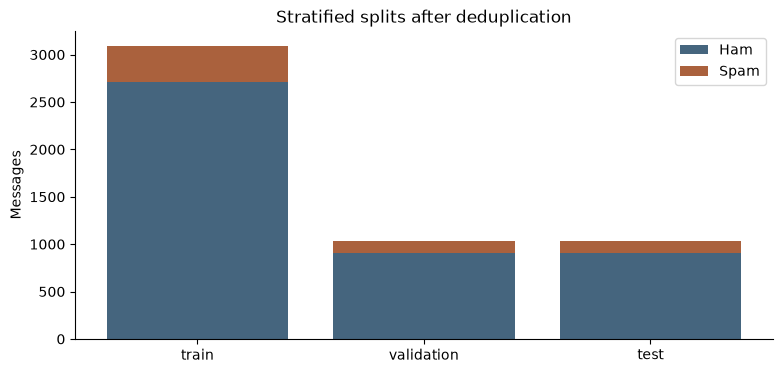

0 No management puzzeles.
0 Awesome, plan to get here any time after like  &lt;#&gt; , I'll text you details in a wee bit
0 I'm outside islands, head towards hard rock and you'll run into me
0 Tmrw. Im finishing 9 doors


In [9]:
names = list(initial["counts"])
ham = [initial["counts"][name]["ham"] for name in names]
spam = [initial["counts"][name]["spam"] for name in names]
plt.bar(names, ham, label="Ham", color=HAM)
plt.bar(names, spam, bottom=ham, label="Spam", color=SPAM)
plt.ylabel("Messages")
plt.title("Stratified splits after deduplication")
plt.legend()
plt.show()
for item in initial["examples"][:4]:
    print(item["label"], item["text"])

### Run and explain

Compare accuracy with spam recall for the always-ham baseline. Inspect repeated message identities and explain why deduplication precedes splitting.

In [10]:
print("Training / validation:", len(X_train), len(X_val))
print("Training spam proportion:", y_train.mean())
baseline = metrics(y_val, np.zeros(len(y_val)))
print("Always-ham accuracy:", baseline["accuracy"])
print("Always-ham recall:", baseline["recall"])

Training / validation: 3095 1032
Training spam proportion: 0.12439418416801293
Always-ham accuracy: 0.875
Always-ham recall: 0.0


**Interpretation:** High accuracy can coexist with zero spam recall. Dataset prevalence and the positive-class convention are necessary to interpret a score.

## 3. Build observable features

**What can we measure before understanding language?**

Begin with quantities a computer can measure directly: characters, tokens, URL prefixes, digits and exclamation marks. They turn each message into five numbers. The URL counter recognizes http://, https:// and www.; it does not validate a domain or detect every possible link. Digits include phone numbers and prices, but also times in legitimate messages.

Compare within-class distributions rather than raw counts: ham is much more common. Overlap matters more than a difference in averages. A feature can be informative without perfectly separating spam from ham. The final histogram bin includes the long tail so the plotted proportions sum to one.

Counts have different scales and skewed distributions. We use log(1+x) to compress long tails and a training-fitted StandardScaler when these features enter numerical models. Applying that fitted transformation to validation messages gives the same coordinates. Two different messages can share all five values, demonstrating what this representation discards.

$$x_j=\text{measured count},\quad u_j=\log(1+x_j),\quad z_j=\frac{u_j-\mu_{j,\mathrm{train}}}{s_{j,\mathrm{train}}}$$

- $x_j$: One raw numerical feature.
- $\mu_{j,\mathrm{train}},s_{j,\mathrm{train}}$: Mean and scale learned only from training observations.
- $\log(1+x)$: Defined even when a count is zero.

**Follow the mechanism**

1. Edit a message and watch its five measured counts change.
2. Switch the feature histogram and compare normalized ham/spam distributions.
3. Inspect the length–digit scatterplot as a projection, then fit a numerical logistic baseline.

### Inspect the implementation: `numerical_features`

This cell is copied from `experiment.py`. Subsequent direct experiments use this editable function. The assignment also updates the shared lab implementation for later fits.

In [11]:
def numerical_features(messages):
    """Hand-designed observations; no labels or fitted statistics are used."""
    return np.asarray([[len(s), len(tokens(s)),
                        len(re.findall(r'https?://|www\.', s, flags=re.I)),
                        sum(c.isdigit() for c in s), s.count('!')]
                       for s in messages], dtype=float)

science.numerical_features = numerical_features

### Inspect the implementation: `build_model`

This cell is copied from `experiment.py`. Subsequent direct experiments use this editable function. The assignment also updates the shared lab implementation for later fits.

In [12]:
def build_model(kind='logistic', representation='count', C=1., k=5):
    """Keep every learned transformation inside the pipeline."""
    if representation == 'numeric' or kind in ('lda', 'gam'):
        steps = [('features', FunctionTransformer(numerical_features)),
                 ('log', FunctionTransformer(np.log1p))]
        if kind == 'gam':
            # Separate spline bases for each input; no feature interactions.
            steps += [('splines', SplineTransformer(n_knots=4, degree=3,
                                                    include_bias=False))]
        steps += [('scale', StandardScaler())]
    else:
        vectorizer = CountVectorizer if representation == 'count' else TfidfVectorizer
        steps = [('vectorizer', vectorizer(token_pattern=TOKEN_PATTERN, min_df=2,
                                          max_features=2500))]
    if kind == 'lda':
        classifier = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    elif kind == 'knn':
        classifier = KNeighborsClassifier(n_neighbors=int(k), algorithm='brute',
                                           metric='euclidean' if representation == 'numeric' else 'cosine')
    else:
        classifier = LogisticRegression(C=float(C), solver='liblinear', max_iter=1000,
                                         random_state=SEED)
    return Pipeline(steps + [('classifier', classifier)])

science.build_model = build_model

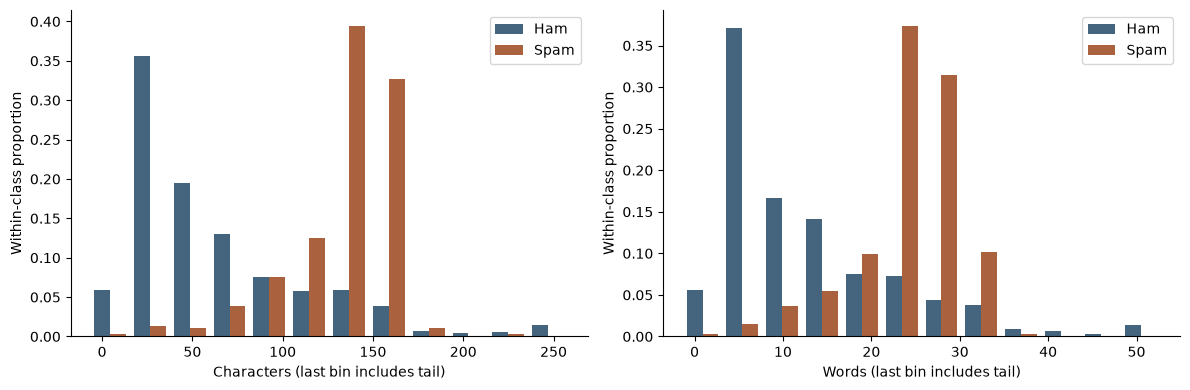

Numerical logistic validation: {'accuracy': 0.9786821705426356, 'precision': 0.9421487603305785, 'recall': 0.8837209302325582, 'f1': 0.9119999999999999, 'confusion': [[896, 7], [15, 114]], 'false_positive_rate': 0.007751937984496124, 'log_loss': 0.07656444884694863, 'average_precision': 0.9504656038391324, 'roc_auc': 0.9825688703460471}


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for j, ax in enumerate(axes):
    d = initial["distributions"][j]
    width = np.diff(d["edges"])[0]
    centers = np.asarray(d["edges"][:-1])
    for label, color in [(0, HAM), (1, SPAM)]:
        ax.bar(centers + label * width * .4, d["groups"][label], width=width * .4, color=color, label="Ham" if label == 0 else "Spam")
    ax.set(xlabel=d["name"] + " (last bin includes tail)", ylabel="Within-class proportion")
    ax.legend()
plt.tight_layout()
plt.show()
numeric_run = lab.fit({"representation": "numeric"})
print("Numerical logistic validation:", numeric_run["validation"])

### Run and explain

Change the text while preserving its character count or digit count. Identify what numerical features detect and what they cannot distinguish.

In [14]:
texts = ["Are you free at 8?", "WIN £1000! Visit https://example.org now!!!"]
print("Characters, words, links, digits, exclamations:")
print(numerical_features(texts))
model = build_model(representation="numeric")
model.fit(X_train, y_train)
print("Numerical baseline AP:", metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"])

Characters, words, links, digits, exclamations:
[[18.  5.  0.  1.  0.]
 [43.  7.  1.  4.  4.]]
Numerical baseline AP: 0.9504656038391324


**Interpretation:** The scatterplot shows two observed features. It does not display every feature or prove that the full classification problem is separable.

## 4. Turn words into vectors

**How can the model use the actual words?**

Our explicit tokenizer lowercases text and extracts alphanumeric words. Construct a vocabulary from training documents, then count occurrences in each document. Every column has a fixed meaning. Transforming a new document reuses this vocabulary: unknown words contribute no new columns. Bag-of-words ignores order and punctuation; the separate numerical representation can preserve punctuation counts.

TF–IDF changes the scale of word evidence. Term frequency is multiplied by inverse document frequency, so words appearing in almost every training document receive less emphasis. Here scikit-learn uses smoothed IDF, log((1+n)/(1+df))+1, followed by L2 normalization of each nonzero document vector. It is a representation choice, not a guarantee of better classification.

The toy matrix deliberately includes every toy token. The real text pipelines keep at most 2,500 features and require a token to appear in at least two training documents. Real matrices remain sparse; only the small teaching matrix is made dense for display. Lowercasing, stopword removal and stemming make different tradeoffs: we retain stopwords and avoid stemming rather than automatically assuming they improve this task.

$$\mathrm{idf}_j=\log\frac{1+n}{1+\mathrm{df}_j}+1,\quad v_j=\mathrm{count}_j\mathrm{idf}_j,\quad x_j=\frac{v_j}{\|\mathbf v\|_2}$$

- $n$: Number of documents used to fit the vectorizer.
- $\mathrm{df}_j$: Number of those documents containing word j.
- $\mathbf x$: L2-normalized TF–IDF vector; an empty vector stays zero.

**Follow the mechanism**

1. Click a vocabulary word to connect its column with occurrences in the toy training documents.
2. Transform your own message and inspect counts, TF–IDF values and ignored words.
3. Compare count and TF–IDF models on the same data split; inspect what bag-of-words loses.

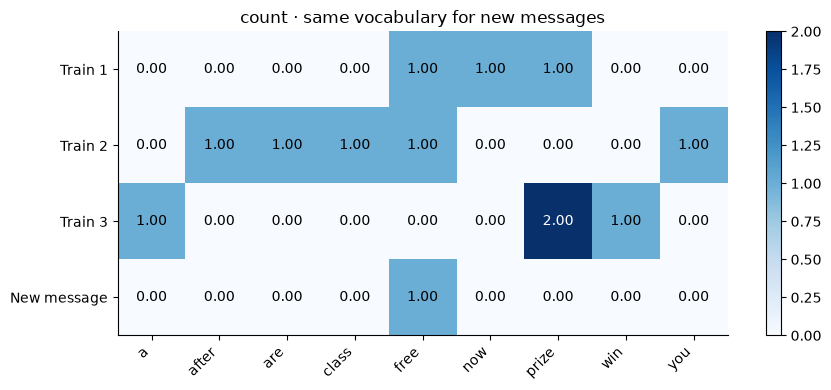

Ignored words: ['meeting', 'tomorrow']


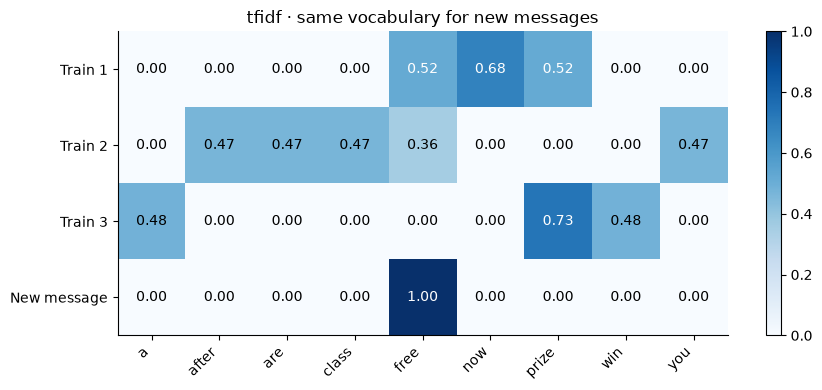

Ignored words: ['meeting', 'tomorrow']


In [15]:
toy = ["free prize now", "are you free after class", "win a prize prize"]
for representation in ["count", "tfidf"]:
    result = lab.vectorize({"documents": toy, "text": "free meeting tomorrow", "representation": representation})
    fig, ax = plt.subplots()
    matrix = np.vstack([result["matrix"], result["transformed"]])
    image = ax.imshow(matrix, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(result["vocabulary"])), result["vocabulary"], rotation=45, ha="right")
    ax.set_yticks(range(4), ["Train 1", "Train 2", "Train 3", "New message"])
    for (row, col), value in np.ndenumerate(matrix):
        ax.text(col, row, f"{value:.2f}", ha="center", va="center", color="white" if value > matrix.max() / 2 else "black")
    ax.set_title(representation + " · same vocabulary for new messages")
    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.show()
    print("Ignored words:", result["unknown"])

### Run and explain

Repeat a word, reorder a sentence, and introduce an unseen word. Explain the different effects on counts and normalized TF–IDF.

In [16]:
vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b[a-z0-9]+\b")
toy = ["free prize now", "are you free after class", "win a prize prize"]
X = vectorizer.fit_transform(toy)
print("Vocabulary:", vectorizer.get_feature_names_out())
print("IDF:", np.round(vectorizer.idf_, 3))
print("New message:", vectorizer.transform(["free meeting tomorrow"]).toarray())

Vocabulary: ['a' 'after' 'are' 'class' 'free' 'now' 'prize' 'win' 'you']
IDF: [1.693 1.693 1.693 1.693 1.288 1.693 1.288 1.693 1.693]
New message: [[0. 0. 0. 0. 1. 0. 0. 0. 0.]]


**Interpretation:** fit learns a representation from training data. transform applies it. Rebuilding the vocabulary for each new message would destroy the meaning of the model’s weights.

## 5. Learn a weighted rule

**How do word counts become a spam score?**

A linear score sums a bias and feature contributions. Positive contributions favor spam; negative ones favor ham. The sigmoid maps this score to a probability-shaped output. At threshold 0.5, the decision is exactly whether the score is nonnegative. The sigmoid does not turn the boundary into a nonlinear one in the chosen feature space.

Fitting minimizes cross-entropy, which responds to confidence as well as correctness. This is the same prediction/loss relationship used for image classification in Tutorial04; sklearn now handles optimization so we can focus on representations and validation. These fitted probabilities need not be calibrated on new populations.

Inspect the contribution w_j x_j for a specific message, not just a list of global weights. A large coefficient contributes nothing when its feature is zero. For TF–IDF, repeating a word can also change other coordinates through normalization. Edit the input and inspect the complete contribution sum, score and probability together.

$$z=b+\sum_j w_jx_j,\quad p=\frac{1}{1+e^{-z}},\quad \ell=-y\log p-(1-y)\log(1-p)$$

- $w_jx_j$: Contribution of feature j for this message.
- $b$: The intercept; it shifts every message’s score.
- $p$: Model estimate of P(spam | represented message).

**Follow the mechanism**

1. Fit a count or TF–IDF classifier using training messages.
2. Inspect a message’s positive and negative contributions and the corresponding sigmoid position.
3. Change one word and explain the new score before comparing validation metrics.

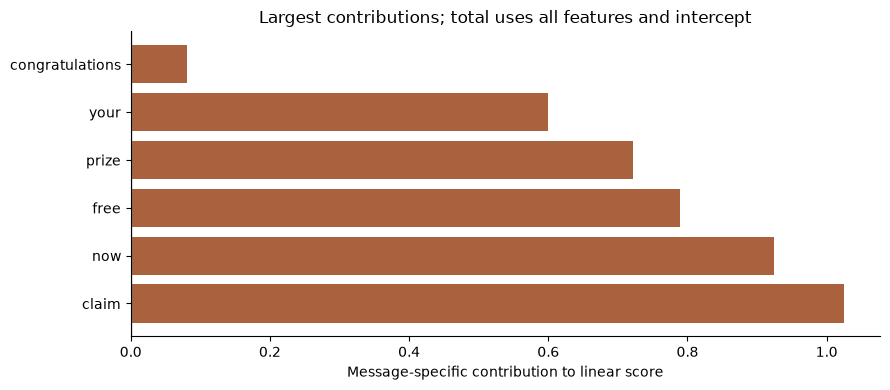

Intercept / score / probability: -4.403354723267205 -0.2636608189796572 0.4344640116979819


In [17]:
count_run = lab.fit({"representation": "count", "C": 1})
tfidf_run = lab.fit({"representation": "tfidf", "C": 1})
explanation = lab.explain({"id": count_run["id"], "text": "Congratulations! Claim your free prize now!"})
items = explanation["contributions"][:14]
plt.barh([item["name"] for item in items], [item["value"] for item in items], color=[SPAM if item["value"] > 0 else HAM for item in items])
plt.axvline(0, color="grey", linewidth=1)
plt.xlabel("Message-specific contribution to linear score")
plt.title("Largest contributions; total uses all features and intercept")
plt.tight_layout()
plt.show()
print("Intercept / score / probability:", explanation["bias"], explanation["score"], explanation["probability"])

### Run and explain

Replace a spam-associated word with a normal word. Explain the contribution change and distinguish the score from the classification decision.

In [18]:
model = build_model(representation="count", C=1)
model.fit(X_train, y_train)
text = "Congratulations claim your free prize now"
x = model[:-1].transform([text])
w = model.named_steps["classifier"].coef_[0]
b = model.named_steps["classifier"].intercept_[0]
z = float((x @ w)[0]) + b
print("Score / probability:", z, 1 / (1 + np.exp(-z)))
print("Validation AP:", metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"])

Score / probability: -0.2636608189796572 0.4344640116979819
Validation AP: 0.962836497746499


**Interpretation:** These contributions explain the fitted model’s calculation. They describe associations and do not show that a word causes spam.

## 6. Control the fitted rule

**Should one rare word receive a huge weight?**

A vocabulary can contain more features than there are spam examples. Some words may look decisive only because they occur in a few training messages. An L2 penalty discourages large coefficients, allowing the model to accept some training error rather than relying strongly on fragile evidence.

In sklearn LogisticRegression, smaller C means stronger regularization. The expression below captures the loss-plus-penalty principle; solver-specific normalization determines the exact mapping from C to lambda. Our liblinear solver also penalizes its synthetic intercept feature. Compare the same representation and split when changing C.

Fit the displayed C values and inspect weight norms alongside training and validation average precision. Strong regularization can underfit; weak regularization can fit training observations better without improving new predictions. The empirical curves need not have a perfect U shape. Do not select a value using test performance.

$$\min_{\mathbf w,b}\;\sum_i\ell(y_i,p_i)+\lambda\|\mathbf w\|_2^2,\qquad C\downarrow\Rightarrow\text{stronger penalty}$$

- $\lambda$: Penalty strength in the conceptual objective.
- $C$: sklearn inverse regularization control.
- $\|\mathbf w\|_2$: Magnitude of the fitted coefficient vector.

**Follow the mechanism**

1. Fit the same model over five C values with the representation fixed.
2. Compare training and validation AP, then inspect how the coefficient norm changes.
3. Carry the need for a less split-sensitive hyperparameter choice into five-fold CV.

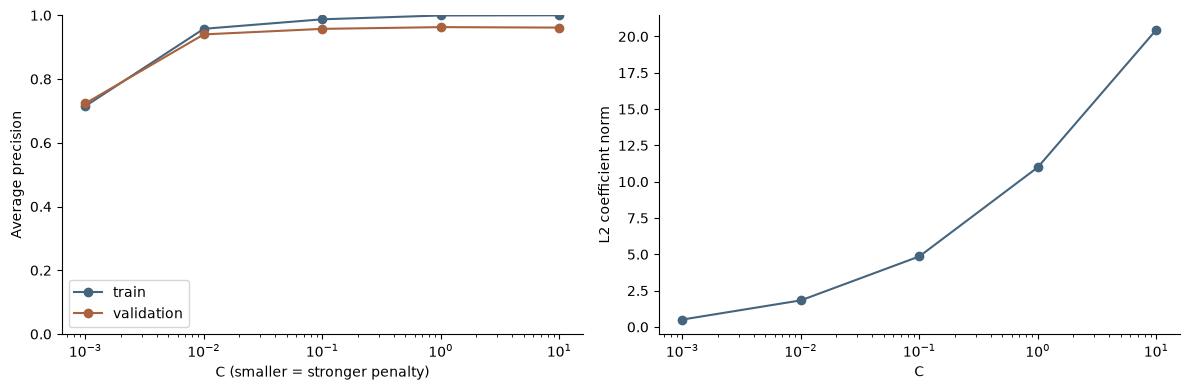

In [19]:
sweep = lab.regularization({"representation": "count"})
Cs = [row["C"] for row in sweep["rows"]]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for split, color in [("train", HAM), ("validation", SPAM)]:
    axes[0].semilogx(Cs, [row[split]["average_precision"] for row in sweep["rows"]], "o-", label=split, color=color)
axes[0].set(xlabel="C (smaller = stronger penalty)", ylabel="Average precision", ylim=(0, 1))
axes[0].legend()
axes[1].semilogx(Cs, sweep["weights"], "o-", color=HAM)
axes[1].set(xlabel="C", ylabel="L2 coefficient norm")
plt.tight_layout()
plt.show()

### Run and explain

Explain whether a larger weight norm helped validation performance in this experiment. Keep the representation fixed while comparing C.

In [20]:
for C in [.001, .01, .1, 1, 10]:
    model = build_model(C=C)
    model.fit(X_train, y_train)
    p = model.predict_proba(X_val)[:, 1]
    norm = np.linalg.norm(model.named_steps["classifier"].coef_)
    print(f"C={C:g}, weight norm={norm:.3f}, validation AP={metrics(y_val, p)["average_precision"]:.3f}")

C=0.001, weight norm=0.509, validation AP=0.724
C=0.01, weight norm=1.830, validation AP=0.940
C=0.1, weight norm=4.855, validation AP=0.957
C=1, weight norm=10.993, validation AP=0.963
C=10, weight norm=20.461, validation AP=0.961


**Interpretation:** Changing C changes fitting. Changing the classification threshold changes decisions after fitting. They solve different problems.

## 7. Select with cross-validation

**What must be fitted again inside each fold?**

Five-fold stratified CV partitions the training split into five parts. Fit on four and score on the remaining part, repeat until each part has served as held-out data, then compare the mean average precision for each C. The spread across folds shows variation in these observed estimates; it is not a formal confidence interval.

Vocabulary, IDF, scaling and spline knots are learned quantities. Fitting them before CV gives the training procedure access to held-out inputs. The pipeline must be fitted independently inside every fold. Words seen only in a held-out fold stay unknown for that fold’s model, exactly as an unfamiliar word would at prediction time.

Select C from training-only CV, refit that pipeline on the complete training split, then compare candidates on validation. Validation also sets the final threshold. This tutorial keeps a separate validation split so these roles are visible. Neither the best CV score nor repeatedly optimized validation performance is an unbiased final report; the untouched test set supplies the final estimate.

$$\mathrm{CV}(C)=\frac{1}{5}\sum_{f=1}^{5}\mathrm{AP}\!\left(y_f,\;\widehat p_{-f,C}(X_f)\right)$$

- $f$: The held-out fold.
- $\widehat p_{-f,C}$: A complete pipeline fitted without fold f.
- $\mathrm{AP}$: Average precision, calculated from the ranking of spam scores.

**Follow the mechanism**

1. Select a held-out fold in the diagram and follow which data fit each pipeline stage.
2. Run CV and inspect every fold score and the vocabulary size learned in that fold.
3. Refit the selected C on all training messages and inspect its validation result.

### Inspect the implementation: `cross_validate`

This cell is copied from `experiment.py`. Subsequent direct experiments use this editable function. The assignment also updates the shared lab implementation for later fits.

In [21]:
def cross_validate(messages, labels, representation='count', values=(.01, .1, 1., 10.)):
    """Fit vocabulary, IDF and model afresh inside EACH training fold."""
    folds = list(StratifiedKFold(5, shuffle=True, random_state=SEED).split(messages, labels))
    rows = []
    for C in values:
        scores, training, vocabulary_sizes = [], [], []
        for train, heldout in folds:
            model = build_model(C=C, representation=representation)
            model.fit(messages[train], labels[train])
            scores.append(average_precision_score(labels[heldout], model.predict_proba(messages[heldout])[:, 1]))
            training.append(average_precision_score(labels[train], model.predict_proba(messages[train])[:, 1]))
            vocabulary_sizes.append(len(model.named_steps['vectorizer'].vocabulary_))
        rows.append({'C': C, 'folds': list(map(float, scores)), 'train': float(np.mean(training)),
                     'mean': float(np.mean(scores)), 'std': float(np.std(scores, ddof=1)),
                     'vocabulary_sizes': vocabulary_sizes})
    return rows

science.cross_validate = cross_validate

C: 0.01 fold AP: [0.931 0.955 0.95  0.94  0.917] mean ± SD: 0.938 0.015
C: 0.1 fold AP: [0.967 0.972 0.97  0.971 0.939] mean ± SD: 0.964 0.014
C: 1.0 fold AP: [0.98  0.973 0.968 0.974 0.946] mean ± SD: 0.968 0.013
C: 10.0 fold AP: [0.97  0.972 0.964 0.963 0.944] mean ± SD: 0.963 0.011


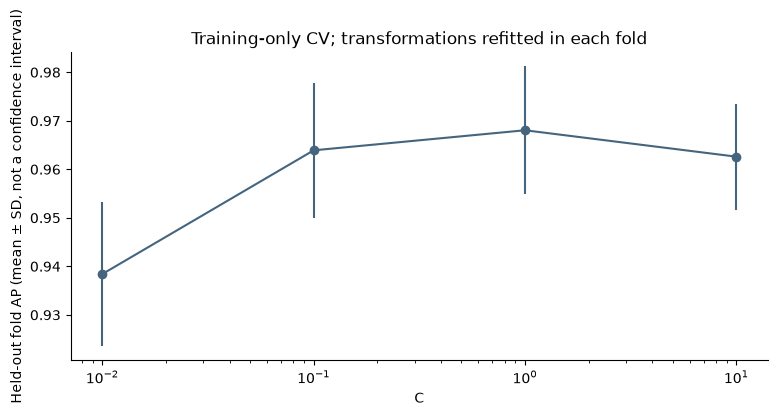

Selected C: 1.0
Fold vocabulary sizes: [2346, 2303, 2336, 2389, 2333]
Held-out words absent from retained fold vocabulary: ['07', '07008009200', '07090298926', '07734396839', '07742676969', '08001950382', '08002888812', '0844', '0870', '08700621170150p', '08701417012150p', '087016248', '08704050406', '08707509020', '08709222922', '087104711148']


In [22]:
cv_result = lab.cv({"representation": "count"})
for row in cv_result["rows"]:
    print("C:", row["C"], "fold AP:", np.round(row["folds"], 3), "mean ± SD:", round(row["mean"], 3), round(row["std"], 3))
means = [row["mean"] for row in cv_result["rows"]]
std = [row["std"] for row in cv_result["rows"]]
plt.errorbar([row["C"] for row in cv_result["rows"]], means, yerr=std, fmt="o-", color=HAM)
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Held-out fold AP (mean ± SD, not a confidence interval)")
plt.title("Training-only CV; transformations refitted in each fold")
plt.show()
print("Selected C:", cv_result["best"])
print("Fold vocabulary sizes:", cv_result["rows"][0]["vocabulary_sizes"])
print("Held-out words absent from retained fold vocabulary:", cv_result["fold_unknown"])

### Run and explain

Follow the vectorizer.fit call in the fold loop. Explain why each vocabulary can have a different size while its corresponding classifier remains valid.

In [23]:
rows = cross_validate(X_train, y_train, representation="count")
for row in rows:
    print("C / fold AP / mean:", row["C"], np.round(row["folds"], 3), round(row["mean"], 3))
print("Selected C:", max(rows, key=lambda r: r["mean"])["C"])

C / fold AP / mean: 0.01 [0.931 0.955 0.95  0.94  0.917] 0.938
C / fold AP / mean: 0.1 [0.967 0.972 0.97  0.971 0.939] 0.964
C / fold AP / mean: 1.0 [0.98  0.973 0.968 0.974 0.946] 0.968
C / fold AP / mean: 10.0 [0.97  0.972 0.964 0.963 0.944] 0.963
Selected C: 1.0


**Interpretation:** CV prevents this preprocessing leakage when used correctly. It does not protect against repeatedly searching many choices and reporting the best observed score as a final estimate.

## 8. Model the class distributions

**What changes if we model the features within each class?**

Logistic regression models a conditional probability directly. LDA instead models features given the class, with a Gaussian distribution per class and a shared covariance, then applies Bayes’ rule with estimated class priors. Shared covariance causes the quadratic terms to cancel, leaving a linear log-odds rule.

Apply LDA to the five transformed numerical features. We use log(1+x), training-fitted scaling and shrinkage covariance estimation to stabilize correlated or rare observations. We do not feed a huge sparse word matrix into a dense Gaussian model: representation and model assumptions must be considered together.

The plot shows standardized log-length and log-digit count. Its ellipses are one-standard-deviation contours from the fitted shared covariance, not regions containing all observations. The line is the two-feature marginal LDA rule including the fitted class priors. Reported validation metrics use all five features, so the plotted line is not the full classifier. Real counts have zeros and non-Gaussian shapes; check errors rather than assuming the model’s distribution is literally true.

$$\log\frac{P(y=1\mid\mathbf x)}{P(y=0\mid\mathbf x)}=(\boldsymbol\mu_1-\boldsymbol\mu_0)^\top\Sigma^{-1}\mathbf x+b$$

- $\boldsymbol\mu_0,\boldsymbol\mu_1$: Fitted feature means for ham and spam.
- $\Sigma$: Shared within-class covariance.
- $b$: Includes the mean-offset terms and log class-prior ratio.

**Follow the mechanism**

1. Fit LDA on the same numerical features used by the numerical logistic baseline.
2. Inspect the means, shared-covariance ellipses and two-feature marginal boundary.
3. Compare validation results with numerical logistic regression to isolate the model change.

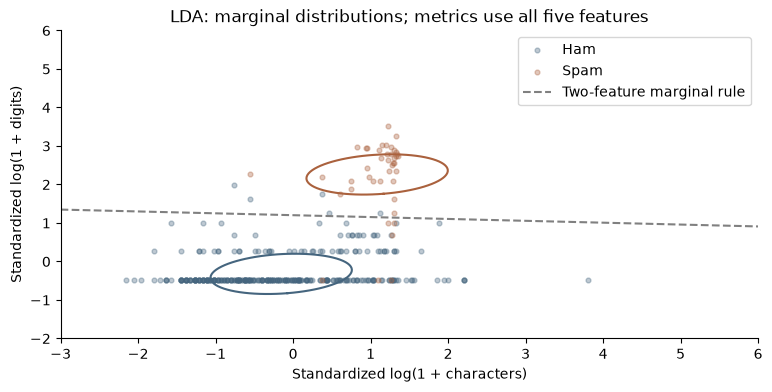

LDA validation: {'accuracy': 0.9786821705426356, 'precision': 0.9349593495934959, 'recall': 0.8914728682170543, 'f1': 0.9126984126984128, 'confusion': [[895, 8], [14, 115]], 'false_positive_rate': 0.008859357696566999, 'log_loss': 0.18860124196358394, 'average_precision': 0.9486376680655596, 'roc_auc': 0.9807231708259292}
Numerical logistic comparison: {'accuracy': 0.9786821705426356, 'precision': 0.9421487603305785, 'recall': 0.8837209302325582, 'f1': 0.9119999999999999, 'confusion': [[896, 7], [15, 114]], 'false_positive_rate': 0.007751937984496124, 'log_loss': 0.07656444884694863, 'average_precision': 0.9504656038391324, 'roc_auc': 0.9825688703460471}


In [24]:
lda_result = lab.lda({})
fig, ax = plt.subplots()
for label, color in [(0, HAM), (1, SPAM)]:
    points = np.asarray([[p["x"], p["y"]] for p in lda_result["points"] if p["label"] == label])
    ax.scatter(points[:, 0], points[:, 1], s=12, alpha=.35, color=color, label="Ham" if label == 0 else "Spam")
    ellipse = np.asarray(lda_result["ellipses"][label])
    ax.plot(ellipse[:, 0], ellipse[:, 1], color=color)
wx, wy = lda_result["boundary"]["w"]
b = lda_result["boundary"]["b"]
x = np.linspace(-3, 6, 50)
if abs(wy) > 1e-9:
    ax.plot(x, -(wx * x + b) / wy, "--", color="grey", label="Two-feature marginal rule")
ax.set(xlabel="Standardized log(1 + characters)", ylabel="Standardized log(1 + digits)", xlim=(-3, 6), ylim=(-2, 6), title="LDA: marginal distributions; metrics use all five features")
ax.legend()
plt.show()
print("LDA validation:", lda_result["run"]["validation"])
print("Numerical logistic comparison:", numeric_run["validation"])

### Run and explain

Compare LDA and logistic regression with the same five features. Explain the shared-covariance assumption and the role of the class priors.

In [25]:
for kind in ["logistic", "lda"]:
    model = build_model(kind=kind, representation="numeric")
    model.fit(X_train, y_train)
    p = model.predict_proba(X_val)[:, 1]
    print(kind, "validation AP:", metrics(y_val, p)["average_precision"])

logistic validation AP: 0.9504656038391324
lda validation AP: 0.9486376680655596


**Interpretation:** Comparing numerical LDA with a word-based model changes both representation and model. Use the numerical logistic baseline when attributing a difference to model assumptions.

## 9. Allow smooth feature effects

**Must each extra character change the score by the same amount?**

An ordinary numerical logistic model assigns a linear effect to each transformed feature. Perhaps increasing a message from 10 to 50 characters matters differently from increasing it from 400 to 440. Replace each linear term with a smooth function, while retaining the logistic link and additive structure.

We implement a binomial additive model with separate cubic spline bases for the five log-transformed numerical features, followed by regularized logistic regression. Spline knots and scaling are fitted on training data. This is a GAM construction; sklearn supplies the basis and classifier rather than a dedicated GAM estimator. The coefficient penalty is L2, not the derivative-based roughness penalty used by some GAM packages.

The curves vary one raw feature at a time, hold the others at their training medians and report the change in log-odds relative to that reference. These are model effects, not empirical conditional spam rates or causal effects. Curves use the observed range up to the 99th percentile; unusual combinations may be sparse. Additivity permits nonlinear individual effects but does not introduce interactions between features.

$$\log\frac{p}{1-p}=b+\sum_{j=1}^{5}f_j(\log(1+x_j)),\quad f_j(u)=\sum_m\beta_{jm}B_{jm}(u)$$

- $f_j$: A smooth fitted effect for numerical feature j.
- $B_{jm}$: Cubic spline basis function m for feature j.
- $\beta_{jm}$: A coefficient fitted using the binomial loss and L2 penalty.

**Follow the mechanism**

1. Fit the additive spline model on the five numerical features.
2. Switch the displayed feature and read its centered effect in log-odds units.
3. Compare numerical logistic regression, LDA and the additive model on validation.

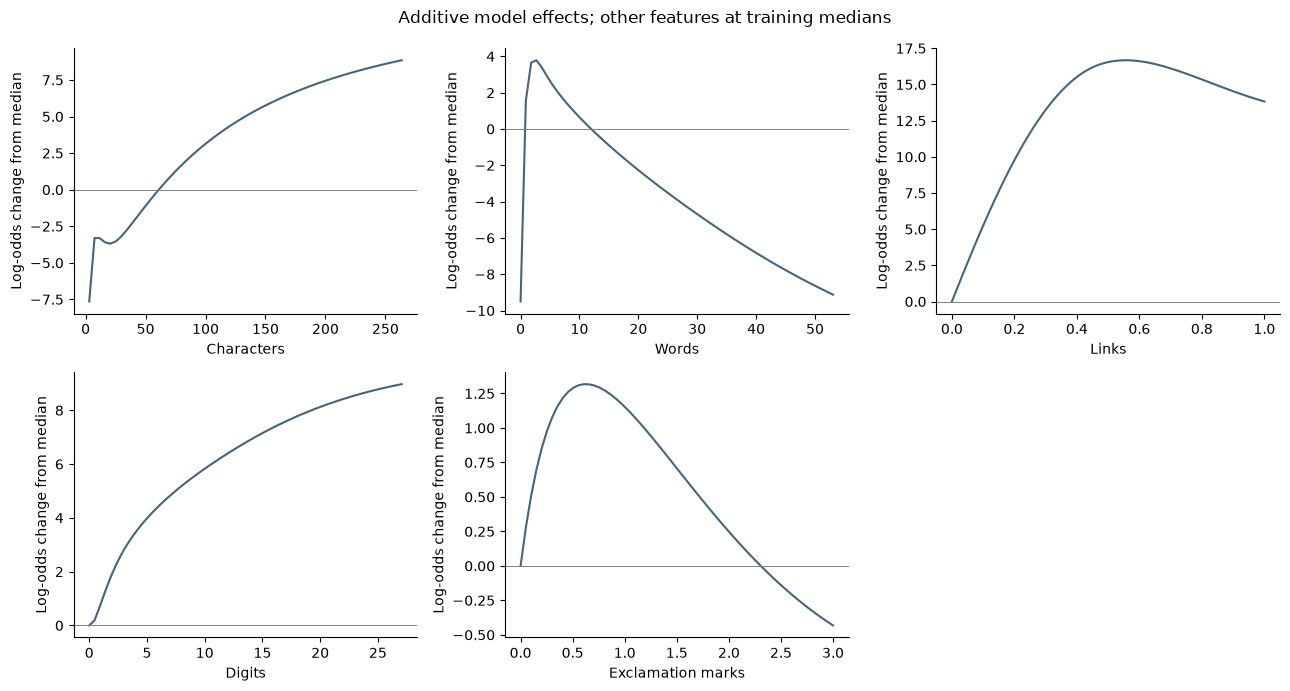

Reference values: [61.0, 12.0, 0.0, 0.0, 0.0]
Additive model validation: {'accuracy': 0.9825581395348837, 'precision': 0.9743589743589743, 'recall': 0.8837209302325582, 'f1': 0.9268292682926831, 'confusion': [[900, 3], [15, 114]], 'false_positive_rate': 0.0033222591362126247, 'log_loss': 0.0653329728499026, 'average_precision': 0.9608942465924359, 'roc_auc': 0.9864577163116914}


In [26]:
gam_result = lab.gam({"C": 1})
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for curve, ax in zip(gam_result["curves"], axes.flat):
    ax.plot(curve["x"], curve["effect"], color=HAM)
    ax.axhline(0, color="grey", linewidth=.7)
    ax.set(xlabel=curve["name"], ylabel="Log-odds change from median")
axes.flat[-1].axis("off")
fig.suptitle("Additive model effects; other features at training medians")
plt.tight_layout()
plt.show()
print("Reference values:", gam_result["reference"])
print("Additive model validation:", gam_result["run"]["validation"])

### Run and explain

Inspect a curved effect and explain how it differs from a constant coefficient. Compare models with the same numerical inputs and identify an interaction the additive model cannot express.

In [27]:
for kind in ["logistic", "gam"]:
    model = build_model(kind=kind, representation="numeric", C=1)
    model.fit(X_train, y_train)
    print(kind, "validation AP:", metrics(y_val, model.predict_proba(X_val)[:, 1])["average_precision"])

logistic validation AP: 0.9504656038391324
gam validation AP: 0.9608942465924359


**Interpretation:** A flexible curve may describe training patterns better. Its usefulness on new messages must still be measured with the same held-out validation data.

## 10. Learn from similar messages

**What makes two messages neighbours?**

KNN stores training examples and classifies a new input using its k closest neighbours. With uniform voting, its spam score is the fraction of spam neighbours. This makes individual predictions easy to inspect, though the fraction is not automatically a calibrated probability.

For numerical features, use Euclidean distance after log transformation and training-fitted standardization. For count or TF–IDF text, use cosine distance to focus on vector direction. These are choices about similarity. A short legitimate message and an unrelated message can still be neighbours when their representation discards important information.

Changing k trades a highly local, potentially noisy decision against a broader vote that can favor the majority class. Text features are sparse and high dimensional; zero overlap and tied distances can make neighbours uninformative. For a zero vector, cosine distance provides no useful direction. Inspect actual neighbour texts, labels and distances alongside validation metrics rather than assuming that “nearest” means semantically similar.

$$\widehat p(\mathbf x)=\frac{1}{k}\sum_{i\in N_k(\mathbf x)}y_i,\qquad d_{\cos}=1-\frac{\mathbf x^\top\mathbf x_i}{\|\mathbf x\|\|\mathbf x_i\|}$$

- $N_k(\mathbf x)$: The k nearest training observations under the chosen distance.
- $k$: Neighbour count; no gradient-based classifier fitting is needed.
- $d_{\cos}$: Cosine distance for nonzero vectors.

**Follow the mechanism**

1. Choose a representation and k, then fit the pipeline with training messages.
2. Enter a message and inspect its nearest training texts, distances and labels.
3. Compare the local vote with a logistic model on the same representation.

In [28]:
knn_run = lab.fit({"kind": "knn", "representation": "tfidf", "k": 5})
neighbours = lab.explain({"id": knn_run["id"], "text": "Claim your free prize now"})
for item in neighbours["neighbors"]:
    print("Distance:", round(item["distance"], 3), "label:", item["label"], "text:", item["text"])
print("Spam vote:", neighbours["probability"])
print("KNN validation:", knn_run["validation"])

Distance: 0.588 label: 0 text: Are you free now?can i call now?
Distance: 0.665 label: 1 text: URGENT This is our 2nd attempt to contact U. Your £900 prize from YESTERDAY is still awaiting collection. To claim CALL NOW 09061702893. ACL03530150PM
Distance: 0.665 label: 1 text: URGENT This is our 2nd attempt to contact U. Your £900 prize from YESTERDAY is still awaiting collection. To claim CALL NOW 09061702893
Distance: 0.678 label: 1 text: Win a £1000 cash prize or a prize worth £5000
Distance: 0.683 label: 1 text: Hi, this is Mandy Sullivan calling from HOTMIX FM...you are chosen to receive £5000.00 in our Easter Prize draw.....Please telephone 09041940223 to claim before 29/03/05 or your prize will be transferred to someone else....
Spam vote: 0.8
KNN validation: {'accuracy': 0.9757751937984496, 'precision': 0.9814814814814815, 'recall': 0.8217054263565892, 'f1': 0.8945147679324895, 'confusion': [[901, 2], [23, 106]], 'false_positive_rate': 0.0022148394241417496, 'log_loss': 0.181035

### Run and explain

Compare k=3 with k=15 under one representation. Inspect the added neighbours and explain how they change the vote and validation errors.

In [29]:
model = build_model(kind="knn", representation="tfidf", k=5)
model.fit(X_train, y_train)
text = "claim your free prize now"
vector = model[:-1].transform([text])
distance, index = model.named_steps["classifier"].kneighbors(vector)
for d, i in zip(distance[0], index[0]):
    print(round(d, 3), "spam" if y_train[i] else "ham", X_train[i])
print("Spam vote:", model.predict_proba([text])[0, 1])

0.588 ham Are you free now?can i call now?
0.665 spam URGENT This is our 2nd attempt to contact U. Your £900 prize from YESTERDAY is still awaiting collection. To claim CALL NOW 09061702893. ACL03530150PM
0.665 spam URGENT This is our 2nd attempt to contact U. Your £900 prize from YESTERDAY is still awaiting collection. To claim CALL NOW 09061702893
0.678 spam Win a £1000 cash prize or a prize worth £5000
0.683 spam Hi, this is Mandy Sullivan calling from HOTMIX FM...you are chosen to receive £5000.00 in our Easter Prize draw.....Please telephone 09041940223 to claim before 29/03/05 or your prize will be transferred to someone else....
Spam vote: 0.8


**Interpretation:** The neighbour view explains which stored observations the classifier used. It also exposes poor similarity choices that a single performance number can hide.

## 11. Choose the final decision

**How should scores become inbox actions?**

A model supplies a score; a threshold turns that score into an action. Raising the threshold generally flags fewer messages and lowers recall. Precision need not improve at every individual threshold. A confusion matrix separates legitimate messages incorrectly blocked (FP) from spam incorrectly accepted (FN), so the consequences remain visible.

Precision is TP/(TP+FP); recall is TP/(TP+FN). The PR curve shows their tradeoff, and average precision summarizes ranking performance without choosing one threshold. Average precision is not the trapezoidal area under the displayed PR curve. Its constant-score reference is the positive-class prevalence. ROC plots recall against false-positive rate; a small FPR can still hide a meaningful number of false alarms in a large ham population.

Use validation to choose a candidate and threshold, considering the intended inbox policy and representative errors. Record the reason, freeze both choices, then evaluate on the test split once. We do not impose a universal cost ratio or a fixed precision target. Under calibrated probabilities and constant error costs, the equation below explains why unequal consequences change the threshold; our fitted probabilities need not meet that calibration assumption.

$$\hat y=\mathbb{1}[p\geq t],\qquad t_{\mathrm{cost}}=\frac{c_{\mathrm{FP}}}{c_{\mathrm{FP}}+c_{\mathrm{FN}}}$$

- $t$: Threshold chosen using development evidence.
- $c_{\mathrm{FP}},c_{\mathrm{FN}}$: Assumed constant costs; the cost formula requires calibrated probabilities.
- $\mathrm{FP},\mathrm{FN}$: Ham blocked versus spam accepted.

**Follow the mechanism**

1. Compare trained candidates, select one and move its validation threshold.
2. Read the linked confusion matrix, PR/ROC curves and actual false alarms or missed spam.
3. Record the model/threshold rationale, freeze the decision and run the final test. Export the complete record.

Candidate comparisons on validation; threshold metrics here use 0.5
run1 logistic numeric C 1.0 k 5 AP 0.95 precision 0.942 recall 0.884
run2 logistic count C 1.0 k 5 AP 0.963 precision 0.974 recall 0.868
run3 logistic tfidf C 1.0 k 5 AP 0.972 precision 1.0 recall 0.767
run4 logistic count C 0.001 k 5 AP 0.724 precision 0.0 recall 0.0
run5 logistic count C 0.01 k 5 AP 0.94 precision 0.987 recall 0.574
run6 logistic count C 0.1 k 5 AP 0.957 precision 0.972 recall 0.814
run7 logistic count C 1.0 k 5 AP 0.963 precision 0.974 recall 0.868
run8 logistic count C 10.0 k 5 AP 0.961 precision 0.958 recall 0.876
run9 logistic count C 1.0 k 5 AP 0.963 precision 0.974 recall 0.868
run10 lda numeric C 1.0 k 5 AP 0.949 precision 0.935 recall 0.891
run11 gam numeric C 1.0 k 5 AP 0.961 precision 0.974 recall 0.884
run12 knn tfidf C 1.0 k 5 AP 0.943 precision 0.981 recall 0.822
Selected validation metrics: {'accuracy': 0.9806201550387597, 'precision': 0.9739130434782609, 'recall': 0.8682170542635659, '

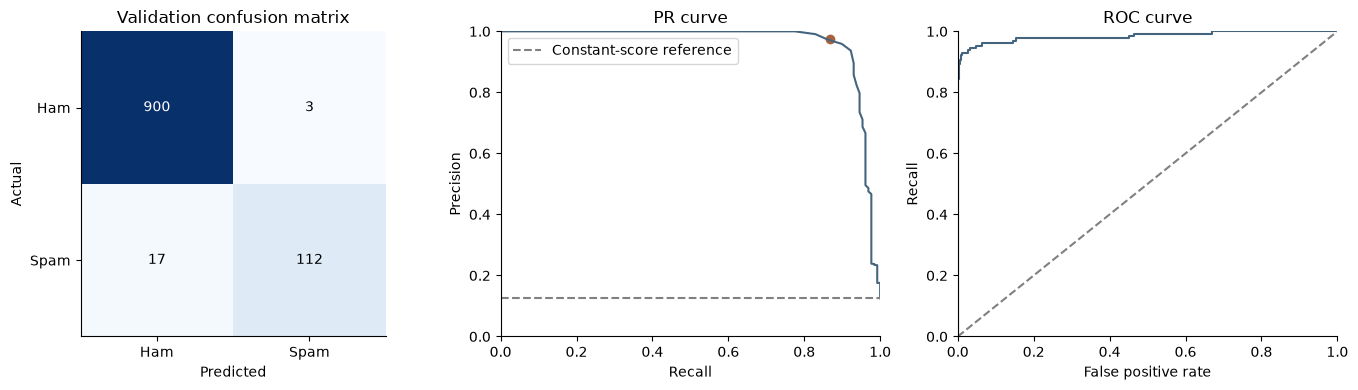

True 1 predicted 0 p 0.003 Hi I'm sue. I am 20 years old and work as a lapdancer. I love sex. Text me live - I'm i my bedroom now. text SUE to 89555. By TextOperator G2 1DA 150ppmsg 18+
True 1 predicted 0 p 0.007 Sorry I missed your call let's talk when you have the time. I'm on 07090201529
True 1 predicted 0 p 0.007 ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT GIV A SHIT. BAILIFF DUE IN DAYS. I O £250 3 WANT £800
True 1 predicted 0 p 0.019 08714712388 between 10am-7pm Cost 10p
True 1 predicted 0 p 0.02 Did you hear about the new "Divorce Barbie"? It comes with all of Ken's stuff!
True 1 predicted 0 p 0.044 Would you like to see my XXX pics they are so hot they were nearly banned in the uk!
True 1 predicted 0 p 0.057 RCT' THNQ Adrian for U text. Rgds Vatian
True 1 predicted 0 p 0.081 88800 and 89034 are premium phone services call 08718711108


In [30]:
print("Candidate comparisons on validation; threshold metrics here use 0.5")
for item in lab.runs.values():
    row = item["row"]
    print(row["id"], row["kind"], row["representation"], "C", row["C"], "k", row["k"], "AP", round(row["validation"]["average_precision"], 3), "precision", round(row["validation"]["precision"], 3), "recall", round(row["validation"]["recall"], 3))

# Edit using validation evidence before executing the final test cell.
selected_id = cv_result["run"]["id"]
threshold = .5
validation_result = lab.evaluate({"id": selected_id, "threshold": threshold})
print("Selected validation metrics:", validation_result["metrics"])
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cm = np.asarray(validation_result["metrics"]["confusion"])
axes[0].imshow(cm, cmap="Blues")
for (r, c), value in np.ndenumerate(cm):
    axes[0].text(c, r, str(value), ha="center", va="center", color="white" if value > cm.max()/2 else "black")
axes[0].set(xticks=[0, 1], yticks=[0, 1], xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"], xlabel="Predicted", ylabel="Actual", title="Validation confusion matrix")
pr, roc = np.asarray(validation_result["pr"]), np.asarray(validation_result["roc"])
axes[1].plot(pr[:, 0], pr[:, 1], color=HAM)
axes[1].axhline(validation_result["prevalence"], ls="--", color="grey", label="Constant-score reference")
axes[1].scatter(validation_result["metrics"]["recall"], validation_result["metrics"]["precision"], color=SPAM)
axes[1].set(xlabel="Recall", ylabel="Precision", title="PR curve", xlim=(0,1), ylim=(0,1))
axes[1].legend()
axes[2].plot(roc[:, 0], roc[:, 1], color=HAM)
axes[2].plot([0,1], [0,1], "--", color="grey")
axes[2].set(xlabel="False positive rate", ylabel="Recall", title="ROC curve", xlim=(0,1), ylim=(0,1))
plt.tight_layout()
plt.show()
for item in validation_result["errors"][:8]:
    print("True", item["label"], "predicted", item["prediction"], "p", round(item["probability"], 3), item["text"])

### Run and explain

Explain a threshold using validation evidence and the error consequences. Inspect both types of errors, then report the frozen decision’s test result and a dataset limitation.

In [31]:
model = build_model(representation="tfidf", C=1)
model.fit(X_train, y_train)
p = model.predict_proba(X_val)[:, 1]
for t in [.2, .5, .8]:
    result = metrics(y_val, p, t)
    print("Threshold:", t, "precision:", round(result["precision"], 3), "recall:", round(result["recall"], 3), "confusion:", result["confusion"])

Threshold: 0.2 precision: 0.917 recall: 0.946 confusion: [[892, 11], [7, 122]]
Threshold: 0.5 precision: 1.0 recall: 0.767 confusion: [[903, 0], [30, 99]]
Threshold: 0.8 precision: 1.0 recall: 0.233 confusion: [[903, 0], [99, 30]]


**Interpretation:** Final test results estimate performance for this fixed research-data split. They do not establish that the same threshold is suitable for modern email or another class prevalence.

## Freeze the decision and evaluate the test set

Write your own rationale using validation evidence, the inbox error tradeoff and a data limitation. This cell runs only when the rationale is nonempty. The lab freezes the selected model and threshold after testing. Restarting a kernel does not make a repeatedly inspected test set unseen again.

In [32]:
reason = ''  # Write your model and threshold rationale before testing.
if reason.strip():
    final_result = lab.final_test({'id': selected_id, 'threshold': threshold, 'reason': reason})
    print(json.dumps(final_result, indent=2))
else:
    print('Record a rationale above, then run the final test once.')

Record a rationale above, then run the final test once.


## Experiment record

Report the baseline, representation/model comparisons, CV result, threshold decision, representative errors and limits of generalizing from historical English SMS to modern email. A higher score alone is not an explanation.

In [33]:
record = {'dataset': 'Original UCI SMS Spam Collection', 'seed': SEED, 'splits': initial['counts'],
          'runs': [{k: v for k, v in item['row'].items() if k not in ('thresholds',)} for item in lab.runs.values()],
          'cv': cv_result['rows'], 'final': lab.final}
Path('tutorial05-results.json').write_text(json.dumps(record, indent=2))
print('Saved tutorial05-results.json')

Saved tutorial05-results.json
